In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [23]:
df=pd.read_csv("wine.csv",usecols=[0,1,2])
df.head()

,Wine,Alcohol,Malic.acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


In [24]:
df.columns=['Wine','Alcohol','Malic.acid']

<Axes: xlabel='Alcohol', ylabel='Density'>

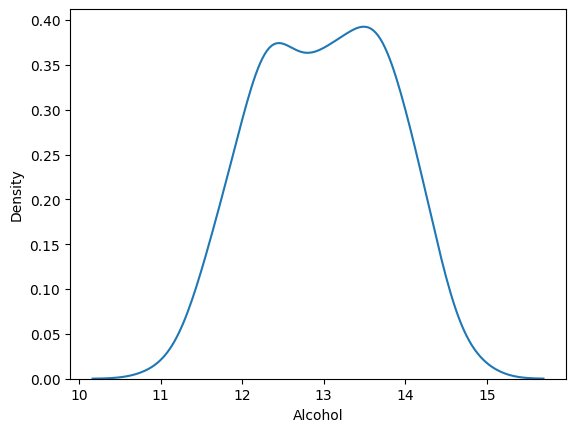

In [25]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic.acid', ylabel='Density'>

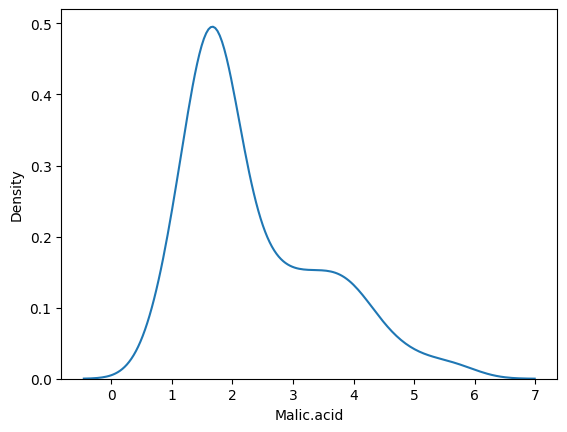

In [26]:
sns.kdeplot(df['Malic.acid'])

<Axes: xlabel='Alcohol', ylabel='Malic.acid'>

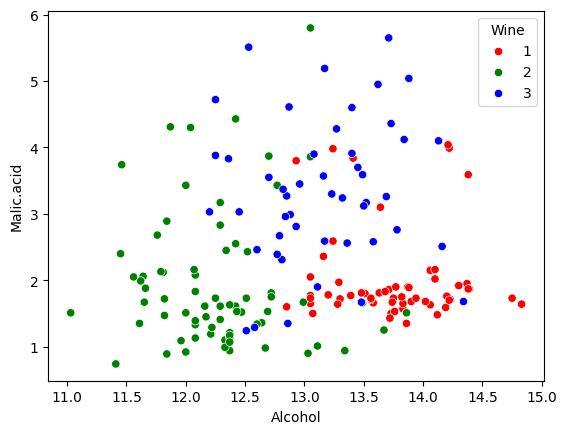

In [27]:
color_dict={
    1:'red',
    2:'green',
    3:'blue'
}
sns.scatterplot(x=df['Alcohol'],y=df['Malic.acid'],hue=df['Wine'],palette=color_dict)


In [28]:
x_train,x_test,y_train,y_test=train_test_split(
    df.drop('Wine',axis=1),
    df['Wine'],
    test_size=0.3,
    random_state=0
)
x_train.shape,x_test.shape

((124, 2), (54, 2))

In [30]:
scaler=MinMaxScaler()
scaler.fit(x_train)
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

/home/ehmad7/Muhammad Ahmad/AI-ML/ML/.venv/lib64/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [33]:
x_train_scaled=pd.DataFrame(x_train_scaled)
x_test_scaled=pd.DataFrame(x_test_scaled)

In [34]:
np.round(x_train.describe(),1)

,Alcohol,Malic.acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [35]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic.acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


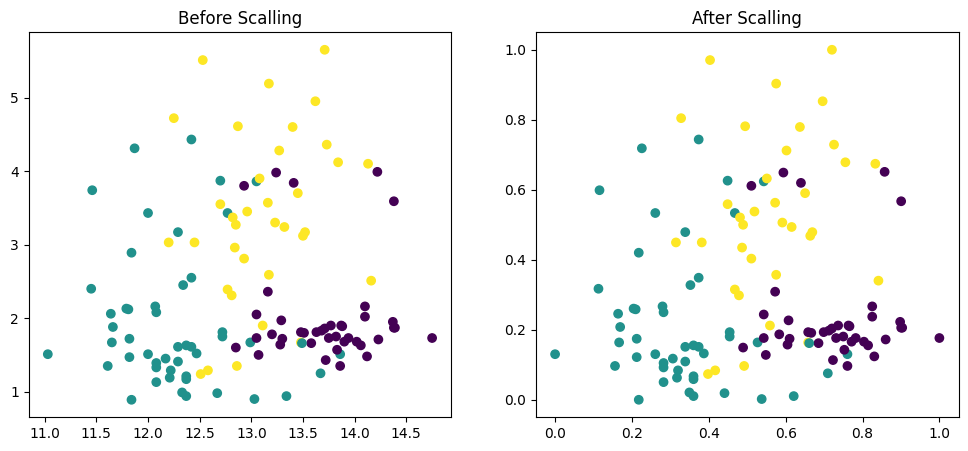

In [38]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Alcohol'],x_train['Malic.acid'],c=y_train)
ax1.set_title('Before Scalling')
ax2.scatter(x_train_scaled['Alcohol'],x_train_scaled['Malic.acid'],c=y_train)
ax2.set_title('After Scalling')
plt.show()